# GM Counter

1. To study determination of beta particle range and maximum energy using the half thickness method.
2. To study the back-scattering of beta particles.
3. To study the production and attenuation of Bremsstrahlung.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import pandas as pd
import math
from scipy.optimize import curve_fit

## Determination of beta particle range and maximum energy using the half thickness method.

 S.No  Absorber Thickness (mm)  Absorber Thickness (mg/cm2)  Counts  Net Count Rate (CPS)
    1                     0.00                         0.00   10922                 59.61
    2                     0.06                        16.26    7776                 42.13
    3                     0.12                        32.52    5985                 32.18
    4                     0.18                        48.78    4518                 24.03
    5                     0.24                        65.04    3439                 18.04
    6                     0.30                        81.30    2552                 13.11
    7                     0.36                        97.56    1988                  9.97
    8                     0.42                       113.82    1470                  7.10
    9                     0.48                       130.08    1150                  5.32
   10                     0.54                       146.34     848                  3.64
Half Thick

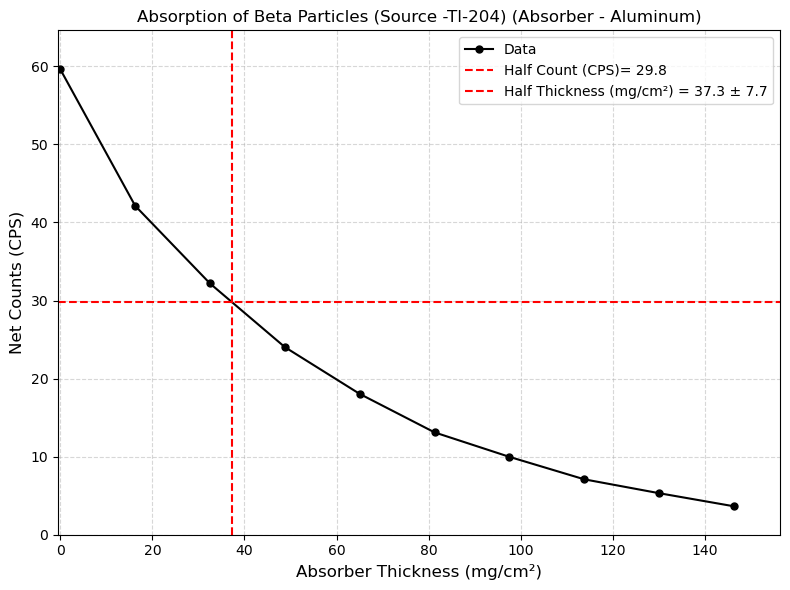

In [37]:
#Tl-204 data
Abst = np.array([0,0.06,0.12,0.18,0.24,0.30,0.36,0.42,0.48,0.54])
counts = np.array([10922,7776,5985,4518,3439,2552,1988,1470,1150,848])  #180s
bkg = np.array([72,69,48,65,67])

original_Abst = Abst.copy()
original_counts = counts.copy()

bg = np.mean(bkg)/60
Abst = Abst*2.71*100
counts = counts/180 - bg 
table_data = {
    'S.No': np.arange(1, len(Abst) + 1),
    'Absorber Thickness (mm)': original_Abst,
    'Absorber Thickness (mg/cm2)': Abst,
    'Counts': original_counts,
    'Net Count Rate (CPS)': np.round(counts, 2) 
}
df = pd.DataFrame(table_data)
print(df.to_string(index=False))

y_max = max(counts)
half_count = y_max / 2

for i in range(len(counts)-1):
    if counts[i] >= half_count and counts[i+1] <= half_count:
        x1, x2 = Abst[i], Abst[i+1]
        y1, y2 = counts[i], counts[i+1]
        half_thickness = x1 + (half_count - y1) * (x2 - x1) / (y2 - y1)
        slope = (y2 - y1) / (x2 - x1)
        delta_y_half = math.sqrt(y_max) / 2
        delta_t_half = abs(delta_y_half / slope)
        print(f"Half Thickness (t_half) = {half_thickness:.2f} mg/cm² ± {delta_t_half:.2f} mg/cm²")
        break

plt.figure(figsize=(8,6))
plt.plot(Abst, counts, 'o-',color='black' ,markersize=5, label='Data')
plt.axhline(half_count, linestyle='--',color='red',
            label=f'Half Count (CPS)= {half_count:.1f}')
plt.axvline(half_thickness, linestyle='--', color='red',
            label=f'Half Thickness (mg/cm²) = {half_thickness:.1f} ± {delta_t_half:.1f}')

plt.xlabel('Absorber Thickness (mg/cm²)', fontsize=12)
plt.ylabel('Net Counts (CPS)', fontsize=12)
plt.title('Absorption of Beta Particles (Source -Tl-204) (Absorber - Aluminum)')
plt.xlim(-0.5, max(Abst) + 10)
plt.ylim(0, max(counts) + 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

 S.No  Absorber Thickness (mm)  Absorber Thickness (mg/cm2)  Counts  Net Counts
    1                     0.00                         0.00   13350      132.43
    2                     0.06                        16.26   11401      112.94
    3                     0.12                        32.52    9971       98.64
    4                     0.18                        48.78    8695       85.88
    5                     0.24                        65.04    8080       79.73
    6                     0.30                        81.30    7349       72.42
    7                     0.36                        97.56    6840       67.33
    8                     0.42                       113.82    6473       63.66
    9                     0.48                       130.08    6210       61.03
   10                     0.54                       146.34    5712       56.05
Half Thickness (t_half) = 102.50 mg/cm² ± 25.49 mg/cm²


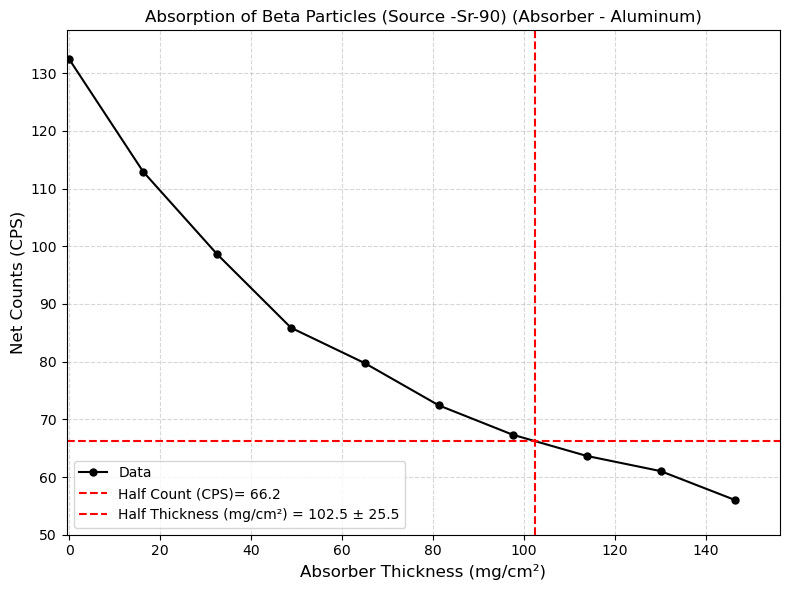

In [ ]:
#Sr-90 data
Abst = np.array([0,0.06,0.12,0.18,0.24,0.30,0.36,0.42,0.48,0.54])
counts = np.array([13350,11401,9971,8695,8080,7349,6840,6473,6210,5712])  #100s
bkg = np.array([72,69,48,65,67])

original_Abst = Abst.copy()
original_counts = counts.copy()

bg = np.mean(bkg)/60
Abst = Abst*2.71*100
counts = counts/100 - bg 
table_data = {
    'S.No': np.arange(1, len(Abst) + 1),
    'Absorber Thickness (mm)': original_Abst,
    'Absorber Thickness (mg/cm2)': Abst,
    'Counts': original_counts,
    'Net Counts': np.round(counts, 3) # Rounded for a cleaner display
}
df = pd.DataFrame(table_data)
print(df.to_string(index=False))


y_max = max(counts)
half_count = y_max / 2

for i in range(len(counts)-1):
    if counts[i] >= half_count and counts[i+1] <= half_count:
        x1, x2 = Abst[i], Abst[i+1]
        y1, y2 = counts[i], counts[i+1]
        half_thickness = x1 + (half_count - y1) * (x2 - x1) / (y2 - y1)
        slope = (y2 - y1) / (x2 - x1)
        delta_y_half = math.sqrt(y_max) / 2
        delta_t_half = abs(delta_y_half / slope)
        print(f"Half Thickness (t_half) = {half_thickness:.2f} mg/cm² ± {delta_t_half:.2f} mg/cm²")
        break

plt.figure(figsize=(8,6))
plt.plot(Abst, counts, 'o-',color='black' ,markersize=5, label='Data')
plt.axhline(half_count, linestyle='--',color='red',
            label=f'Half Count (CPS)= {half_count:.1f}')
plt.axvline(half_thickness, linestyle='--', color='red',
            label=f'Half Thickness (mg/cm²) = {half_thickness:.1f} ± {delta_t_half:.1f}')

plt.xlabel('Absorber Thickness (mg/cm²)', fontsize=12)
plt.ylabel('Net Counts (CPS)', fontsize=12)
plt.title('Absorption of Beta Particles (Source -Sr-90) (Absorber - Aluminum)')
plt.xlim(-0.5, max(Abst) + 10)
plt.ylim(50, max(counts) + 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Production and attenuation of Bremsstrahlung 

(No analysis.. direct inference from data.. check report)

## Back-scattering of beta particles

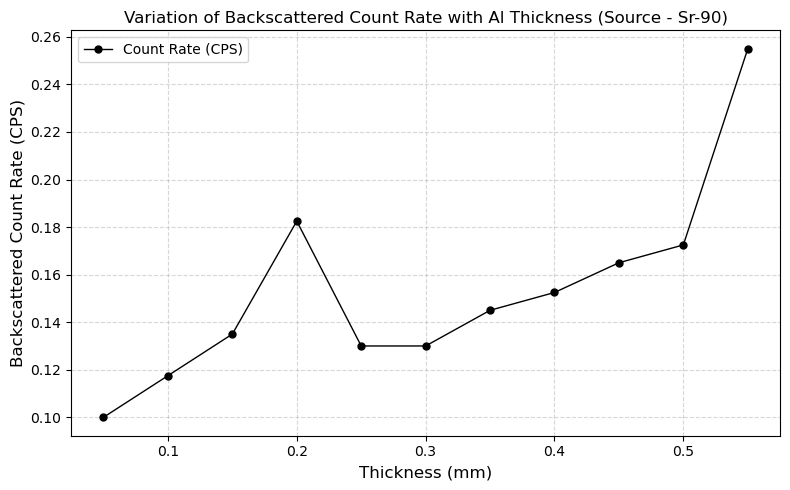

In [39]:
thickness = np.array([0.55,0.50,0.45,0.40,0.35,0.30,0.25,0.20,0.15,0.10,0.05])
Counts = np.array([227,210.5,209,206.5,205,202,202,212.5,203,199.5,196])
Counts = Counts - 176
t = 200 
Counts = Counts / t

plt.figure(figsize=(8,5))
plt.plot(thickness, Counts, 'o-', linewidth=1,
         label='Count Rate (CPS)', color='black', markersize=5)
plt.xlabel('Thickness (mm)', fontsize=12)
plt.ylabel('Backscattered Count Rate (CPS)', fontsize=12)
plt.title('Variation of Backscattered Count Rate with Al Thickness (Source - Sr-90)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()